In [1]:
import os
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

In [2]:
d = np.load("data/dataset_splits.npz")
X_train = d["X_train"]
X_test  = d["X_test"]
y_train = d["y_train"].ravel()
y_test  = d["y_test"].ravel()

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (1254, 1000) X_test: (314, 1000)
y_train: (1254,) y_test: (314,)


In [3]:
#mertics helper 
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bias(y_true, y_pred):
    return float(np.mean(y_pred - y_true))

def rpd(y_true, y_pred):
    return float(np.std(y_true, ddof=1) / rmse(y_true, y_pred))

def metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "Bias": bias(y_true, y_pred),
        "RPD": rpd(y_true, y_pred),
    }

In [4]:
#MSC preprocessing

def msc(X):
    """
    Multiplicative Scatter Correction (MSC)
    Each spectrum is linearly regressed against the mean spectrum.
    """
    mean_spectrum = np.mean(X, axis=0)
    X_msc = np.zeros_like(X, dtype=np.float64)

    for i in range(X.shape[0]):
        slope, intercept = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - intercept) / slope

    return X_msc

X_train_msc = msc(X_train)
X_test_msc  = msc(X_test)

print("X_train_msc:", X_train_msc.shape, "X_test_msc:", X_test_msc.shape)

X_train_msc: (1254, 1000) X_test_msc: (314, 1000)


In [5]:
# Train Ridge with CV
seed = 42
cv = KFold(n_splits=10, shuffle=True, random_state=seed)

ridge = Ridge()
param_grid = {"alpha": [0.01, 0.1, 1, 10, 100, 500, 1000]}

grid = GridSearchCV(
    ridge,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_msc, y_train)

best_ridge = grid.best_estimator_
print("Best alpha:", grid.best_params_)
print("CV best R2:", grid.best_score_)

Fitting 10 folds for each of 7 candidates, totalling 70 fits
Best alpha: {'alpha': 0.01}
CV best R2: 0.5405771098137612


In [6]:
# Predict + evaluate

pred_train = best_ridge.predict(X_train_msc).reshape(-1)
pred_test  = best_ridge.predict(X_test_msc).reshape(-1)

print("pred_train shape:", pred_train.shape)  # (1254,)
print("pred_test shape :", pred_test.shape)   # (314,)

print("TRAIN metrics:", metrics(y_train, pred_train))
print("TEST  metrics:", metrics(y_test, pred_test))

pred_train shape: (1254,)
pred_test shape : (314,)
TRAIN metrics: {'R2': 0.5772290300005021, 'RMSE': 9.200776220420655, 'Bias': -2.0634070387113086e-13, 'RPD': 1.5385820222268007}
TEST  metrics: {'R2': 0.6076328460383802, 'RMSE': 9.695631304632878, 'Bias': -0.049709233614410674, 'RPD': 1.5989921552927473}


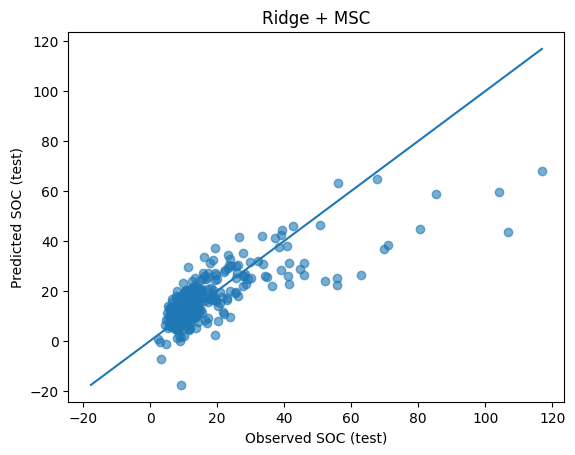

In [7]:
# scatter Plot

plt.figure()
plt.scatter(y_test, pred_test, alpha=0.6)
mn = min(y_test.min(), pred_test.min())
mx = max(y_test.max(), pred_test.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed SOC (test)")
plt.ylabel("Predicted SOC (test)")
plt.title("Ridge + MSC")
plt.show()

In [8]:
os.makedirs("data/predictions", exist_ok=True)

np.savez_compressed(
    "data/predictions/ridge_msc_preds.npz",
    pred_train=pred_train.astype(np.float64),
    pred_test=pred_test.astype(np.float64)
)

np.savez_compressed(
    "data/predictions/msc_preprocessed_spectra.npz",
    X_train_msc=X_train_msc,
    X_test_msc=X_test_msc
)

print("Saved:")
print(" - data/predictions/ridge_msc_preds.npz")
print(" - data/predictions/msc_preprocessed_spectra.npz")

Saved:
 - data/predictions/ridge_msc_preds.npz
 - data/predictions/msc_preprocessed_spectra.npz
